# CNN for CIFAR-10 Image Classification

In [27]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

2.7.1+cu128
True
NVIDIA GeForce GTX 1650


## Project Overview

This project implements and trains a Convolutional Neural Network (CNN) for image classification on the [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset.

The input consists of RGB images with a resolution of `32 × 32 × 3`. The network follows the architecture described below:

| Layer     | Filters/Neurons | Kernel Size | Stride | Feature Map Size |
|-----------|-----------------|-------------|--------|------------------|
| Conv 1    | 32              | 3×3         | 1      | 30 × 30 × 32     |
| Conv 2    | 64              | 3×3         | 1      | 28 × 28 × 64     |
| Conv 3    | 128             | 3×3         | 1      | 26 × 26 × 128    |
| Pool 4    | 128             | 2×2         | 2      | 13 × 13 × 128    |
| Conv 5    | 256             | 3×3         | 1      | 11 × 11 × 256    |
| Conv 6    | 512             | 3×3         | 1      | 9 × 9 × 512       |
| Pool 7    | 512             | 3×3         | 3      | 3 × 3 × 512       |
| Conv 8    | 1024            | 3×3         | 1      | 1 × 1 × 1024      |
| Linear 9  | 100             | –           | –      | 100               |
| Linear 10 | 10              | –           | –      | 10                |

The model is trained for 50 epochs and evaluated on the validation set during training.

Training and validation metrics are logged using **TensorBoard**, including:

- Validation loss
- Validation accuracy
- Training loss

The final model achieves an accuracy of approximately **73%** on the CIFAR-10 dataset.

## Package Imports and Environment Setup

This section imports the libraries required for implementing and training the convolutional neural network on the CIFAR-10 dataset. If a CUDA-compatible GPU is available, the training will be performed on the GPU.

In [28]:
# Import required libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt


# Detect the device used for training: GPU if available, otherwise CPU

device: torch.device

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using PyTorch version:", torch.__version__, " Device:", device)

Using PyTorch version: 2.7.1+cu128  Device: cuda


## Dataset Preparation and DataLoader

The data is loaded from the CIFAR-10 dataset, which consists of RGB images of size 32x32, with 50,000 images for training and 10,000 images for validation. DataLoader is used to generate minibatches of size 64 and shuffle the training data at each epoch (`shuffle=True`).

The minibatch shape is `[batch_size, channels, height, width]`, confirmed by displaying the first batch.

In [29]:
# Minibatch size
batch_size: int = 64


# CIFAR-10: 50,000 training images, 10,000 validation images
# ToTensor converts PIL images into PyTorch tensors with values in [0, 1]

train_dataset: datasets.CIFAR10 = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

assert len(train_dataset) == 50000


validation_dataset: datasets.CIFAR10 = datasets.CIFAR10(
    "./data",
    train=False,
    transform=transforms.ToTensor()
)

assert len(validation_dataset) == 10000


# DataLoader manages minibatches and shuffling for training

train_loader: torch.utils.data.DataLoader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

validation_loader: torch.utils.data.DataLoader = torch.utils.data.DataLoader(
    dataset=validation_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [30]:
# Display information about the first minibatch.
# Except for the last minibatch, all minibatches will have the same shape.

# Display the shape of the first minibatch for verification

X_train: torch.Tensor
y_train: torch.Tensor

for (X_train, y_train) in train_loader:
    print("X_train:", X_train.size(), "type:", X_train.type())
    print("y_train:", y_train.size(), "type:", y_train.type())
    break

X_train: torch.Size([64, 3, 32, 32]) type: torch.FloatTensor
y_train: torch.Size([64]) type: torch.LongTensor


## Visualizing Training Set Examples


To verify that the CIFAR-10 dataset was loaded correctly and to inspect some sample images, the first 16 images from a training mini-batch are displayed together with their labels.

This visualization confirms the RGB format of the images (3 channels) and provides examples from different CIFAR-10 classes, such as airplane, bird, cat, deer, dog, frog, horse, ship, and truck.

The tensor shape `[64, 3, 32, 32]` is converted to the format required by `imshow` (`H × W × C`) by transposing the channel dimension.

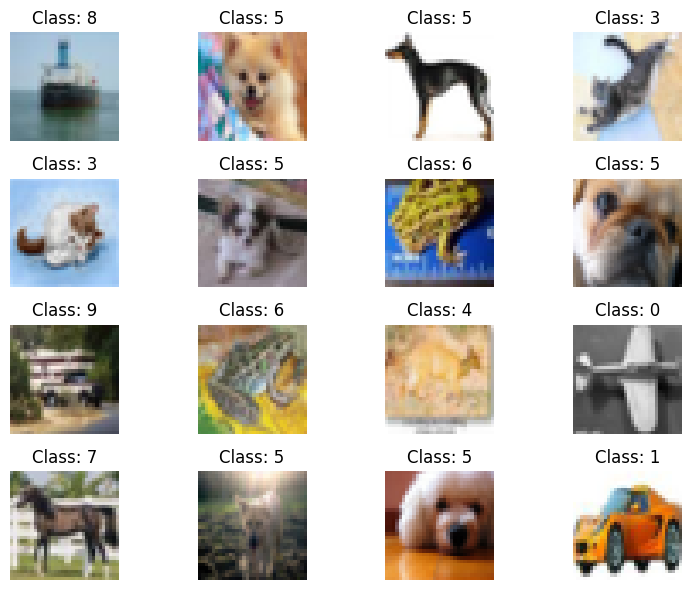

In [31]:
# Display the first 16 images from the training mini-batch

plt.figure(figsize=(8, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.axis('off')
    plt.imshow(X_train[i].numpy().transpose(1, 2, 0))
    plt.title('Class: ' + str(y_train[i].item()))

plt.tight_layout()

The images are colored and belong to visually distinct classes, which makes a convolutional neural network suitable for automatically extracting relevant features. This visualization confirms that the data was loaded correctly and is suitable for training an image classification model.

## Training, Validation, and Visualization Utilities

This section defines the functions used to train and evaluate the convolutional neural network.

The `train()` function iterates over the training dataset, performs forward propagation, computes the loss, applies backpropagation, and updates the model weights.

The `validate()` function evaluates the model on the validation dataset by computing both the loss and the classification accuracy.

Both functions log the loss and accuracy values to TensorBoard, allowing the model's performance to be monitored throughout training.

In [32]:
def train(
    model: nn.Module,
    epoch: int,
    writer: SummaryWriter,
    log_interval: int = 200
) -> None:
    """Train the model for one epoch and log the training loss to TensorBoard.

    Args:
        model (nn.Module): Neural network to be trained.
        epoch (int): Current epoch number, used for logging.
        writer (SummaryWriter): TensorBoard writer.
        log_interval (int): Number of batches between loss logs.
    """

    # Set the model to training mode
    model.train()

    # Iterate over the training batches
    batch_idx: int
    data: torch.Tensor
    target: torch.Tensor

    for batch_idx, (data, target) in enumerate(train_loader):

        # Move data to the selected device
        data = data.to(device)
        target = target.to(device)

        # Reset the gradients
        optimizer.zero_grad()

        # Forward pass
        output: torch.Tensor = model(data)

        # Calculate the loss
        loss: torch.Tensor = criterion(output, target)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        if batch_idx % log_interval == 0:
            print(
                'Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch,
                    batch_idx * len(data),
                    len(train_loader.dataset),
                    100. * batch_idx / len(train_loader),
                    loss.item()
                )
            )

            writer.add_scalar(
                'Loss/train',
                loss.item(),
                epoch * len(train_loader) + batch_idx
            )

In [33]:
def validate(
    model: nn.Module,
    writer: SummaryWriter,
    epoch: int
) -> None:
    """Evaluate the model on the validation dataset and log loss and accuracy to TensorBoard.

    Args:
        model (nn.Module): Neural network to be evaluated.
        writer (SummaryWriter): TensorBoard writer used to log validation metrics.
        epoch (int): Current epoch number, used for logging.
    """

    # Set the model to evaluation mode
    model.eval()

    val_loss: float
    correct: int
    data: torch.Tensor
    target: torch.Tensor
    output: torch.Tensor
    pred: torch.Tensor

    with torch.no_grad():
        val_loss, correct = 0, 0

        # Iterate over the validation batches
        for data, target in validation_loader:
            data = data.to(device)
            target = target.to(device)

            # Forward pass
            output = model(data)

            # Calculate validation loss
            val_loss += criterion(output, target).item()

            # Get the predicted class
            pred = output.argmax(dim=1)

            # Count correctly classified samples
            correct += pred.eq(target).sum().item()

        # Calculate average validation loss and accuracy
        val_loss /= len(validation_loader)
        accuracy: float = 100. * correct / len(validation_loader.dataset)

    print(
        '\nValidation set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
            val_loss,
            correct,
            len(validation_loader.dataset),
            accuracy
        )
    )

    # Log validation metrics to TensorBoard
    writer.add_scalar("Loss/validation", val_loss, epoch)
    writer.add_scalar("Accuracy/validation", accuracy, epoch)

## Model Definition

In this section, the convolutional neural network is implemented according to the architecture specified in the assignment.

The model consists of six convolutional layers followed by two fully connected layers. ReLU is used as the activation function between layers.

Max-pooling layers are used to reduce the spatial dimensions of the feature maps. The final fully connected layer produces 10 outputs corresponding to the 10 CIFAR-10 classes.

The model contains **6,391,702 trainable parameters**, making it significantly more complex than architectures such as LeNet-5 and allowing it to learn richer visual representations.

In [34]:
class MyNet(nn.Module):
    """Convolutional neural network for CIFAR-10 image classification."""

    conv1: nn.Conv2d
    conv2: nn.Conv2d
    conv3: nn.Conv2d
    pool4: nn.MaxPool2d

    conv5: nn.Conv2d
    conv6: nn.Conv2d
    pool7: nn.MaxPool2d

    conv8: nn.Conv2d

    fc9: nn.Linear
    fc10: nn.Linear

    def __init__(self) -> None:
        super(MyNet, self).__init__()

        # CNN architecture according to the assignment requirements

        # First feature extraction block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second feature extraction block
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3)
        self.conv6 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3)
        self.pool7 = nn.MaxPool2d(kernel_size=3, stride=3)

        # Final convolutional layer
        self.conv8 = nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3)

        # Classification layers
        self.fc9 = nn.Linear(in_features=1024, out_features=100)
        self.fc10 = nn.Linear(in_features=100, out_features=10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Performs the forward pass through the network.

        Args:
            x (torch.Tensor): Batch of images with shape
                (batch_size, 3, 32, 32).

        Returns:
            torch.Tensor: Output logits with shape (batch_size, 10).
        """

        # First convolutional block
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = self.pool4(x)

        # Second convolutional block
        x = torch.relu(self.conv5(x))
        x = torch.relu(self.conv6(x))
        x = self.pool7(x)

        # Final convolution
        x = torch.relu(self.conv8(x))

        # Flatten before the fully connected layers
        x = x.view(x.size(0), -1)

        # Classification layers
        x = torch.relu(self.fc9(x))
        x = self.fc10(x)

        # No softmax is applied here because it is handled
        # internally by CrossEntropyLoss.
        return x

### Model Instantiation and Summary

In [35]:
my_net = MyNet()
summary(my_net, (3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 30, 30]          896
├─Conv2d: 1-2                            [-1, 64, 28, 28]          18,496
├─Conv2d: 1-3                            [-1, 128, 26, 26]         73,856
├─MaxPool2d: 1-4                         [-1, 128, 13, 13]         --
├─Conv2d: 1-5                            [-1, 256, 11, 11]         295,168
├─Conv2d: 1-6                            [-1, 512, 9, 9]           1,180,160
├─MaxPool2d: 1-7                         [-1, 512, 3, 3]           --
├─Conv2d: 1-8                            [-1, 1024, 1, 1]          4,719,616
├─Linear: 1-9                            [-1, 100]                 102,500
├─Linear: 1-10                           [-1, 10]                  1,010
Total params: 6,391,702
Trainable params: 6,391,702
Non-trainable params: 0
Total mult-adds (M): 201.13
Input size (MB): 0.01
Forward/backward pass size (MB): 1.82
Params size (MB): 24.38
E

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 30, 30]          896
├─Conv2d: 1-2                            [-1, 64, 28, 28]          18,496
├─Conv2d: 1-3                            [-1, 128, 26, 26]         73,856
├─MaxPool2d: 1-4                         [-1, 128, 13, 13]         --
├─Conv2d: 1-5                            [-1, 256, 11, 11]         295,168
├─Conv2d: 1-6                            [-1, 512, 9, 9]           1,180,160
├─MaxPool2d: 1-7                         [-1, 512, 3, 3]           --
├─Conv2d: 1-8                            [-1, 1024, 1, 1]          4,719,616
├─Linear: 1-9                            [-1, 100]                 102,500
├─Linear: 1-10                           [-1, 10]                  1,010
Total params: 6,391,702
Trainable params: 6,391,702
Non-trainable params: 0
Total mult-adds (M): 201.13
Input size (MB): 0.01
Forward/backward pass size (MB): 1.82
Params size (MB): 24.38
E

## Training and Validation


In this section, the `MyNet` model is trained on the CIFAR-10 dataset for 50 epochs.

The model is moved to the GPU if one is available. **SGD with momentum** and **L2 regularization (weight decay)** are used as the optimization strategy to help prevent overfitting.

The loss function used is `CrossEntropyLoss`, which is suitable for multi-class classification.

During each epoch, both `train()` and `validate()` are called to monitor the model's performance. The loss and accuracy values are logged to TensorBoard for visualization.

In [36]:
# Move the model to the GPU if available
my_net.to(device)

# Optimizer: SGD with momentum and L2 regularization
optimizer: torch.optim.Optimizer = torch.optim.SGD(
    my_net.parameters(),
    lr=0.1,
    momentum=0.1,
    weight_decay=1e-3
)

# TensorBoard writer
writer: SummaryWriter = SummaryWriter('runs/CNN_CIFAR10')

# Loss function used for training
criterion: nn.Module = nn.CrossEntropyLoss()

In [ ]:
%%time

# Number of training epochs
epochs: int = 50

# Main training and validation loop
epoch: int
for epoch in range(1, epochs + 1):
    train(my_net, epoch, writer, 100)
    validate(my_net, writer, epoch)

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.309343
Train Epoch: 1 [6400/50000 (13%)]	Loss: 2.314750
Train Epoch: 1 [12800/50000 (26%)]	Loss: 2.310096
Train Epoch: 1 [19200/50000 (38%)]	Loss: 2.302661
Train Epoch: 1 [25600/50000 (51%)]	Loss: 2.295335
Train Epoch: 1 [32000/50000 (64%)]	Loss: 2.299352
Train Epoch: 1 [38400/50000 (77%)]	Loss: 2.278116
Train Epoch: 1 [44800/50000 (90%)]	Loss: 2.270736

Validation set: Average loss: 2.1798, Accuracy: 1954/10000 (20%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 2.139916
Train Epoch: 2 [6400/50000 (13%)]	Loss: 2.206073
Train Epoch: 2 [12800/50000 (26%)]	Loss: 2.103672
Train Epoch: 2 [19200/50000 (38%)]	Loss: 1.936773
Train Epoch: 2 [25600/50000 (51%)]	Loss: 1.981709
Train Epoch: 2 [32000/50000 (64%)]	Loss: 1.913753
Train Epoch: 2 [38400/50000 (77%)]	Loss: 1.762894
Train Epoch: 2 [44800/50000 (90%)]	Loss: 1.759820

Validation set: Average loss: 1.9153, Accuracy: 3169/10000 (32%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 2.009026
Train Epoch: 3 [6400/50000 (13%)]

The convolutional neural network implemented for CIFAR-10 achieved a maximum validation accuracy of approximately 73%. Throughout training, the training loss continued to decrease, while the validation loss started to increase after approximately 30 epochs, indicating the onset of overfitting.

The evolution of the loss and accuracy observed in TensorBoard confirms this trend. Early stopping or additional regularization techniques could be used to reduce overfitting and stabilize the model's performance.

## TensorBoard Visualization of Loss and Accuracy

This section presents the graphs showing the evolution of the loss function and validation accuracy throughout model training.

The recorded values are stored in the `runs/` directory, allowing TensorBoard to visualize the training progress and compare different model runs.

In [ ]:
# List the existing files to confirm that TensorBoard logs were generated

%ls
%ls runs

 Volume in drive D is alte fisiere
 Volume Serial Number is 2A0A-D44A

 Directory of d:\SmartGit\cifar10-cnn-pytorch

09.08.2026  19:33    <DIR>          .
09.08.2026  19:33    <DIR>          ..
09.08.2026  18:12           160.110 CNN-CIFAR10-PyTorch.ipynb
09.08.2026  19:25    <DIR>          data
09.08.2026  17:42             1.587 README.md
09.08.2026  18:02                99 requirements.txt
09.08.2026  19:33    <DIR>          runs
               3 File(s)        161.796 bytes
               4 Dir(s)  788.487.081.984 bytes free
 Volume in drive D is alte fisiere
 Volume Serial Number is 2A0A-D44A

 Directory of d:\SmartGit\cifar10-cnn-pytorch\runs

09.08.2026  19:33    <DIR>          .
09.08.2026  19:33    <DIR>          ..
09.08.2026  20:12    <DIR>          CNN_CIFAR10
               0 File(s)              0 bytes
               3 Dir(s)  788.487.081.984 bytes free


In [ ]:
# Load the TensorBoard extension

%load_ext tensorboard

# Launch TensorBoard to visualize the training metrics

%tensorboard --logdir=runs/CNN_CIFAR10

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 676), started 0:00:15 ago. (Use '!kill 676' to kill it.)

The training loss decreases throughout the training process, while the validation accuracy improves, indicating that the model progressively learns relevant features from the CIFAR-10 images.

The implemented CNN achieves a maximum validation accuracy of approximately **73%** on CIFAR-10. The evolution of the training and validation loss shows an initial learning phase followed by stagnation and fluctuations, with the increasing validation loss indicating the onset of **overfitting**.

The TensorBoard graphs confirm the successful training of the model and provide a visual overview of its performance throughout the training process.